# Basics of TensorFlow & Keras — Building a Simple Neural Network


## 1. What is TensorFlow? What is Keras?

In the theory lecture, we learned *what* neural networks are and *how* they learn. Now we need a tool to actually build them. Writing backpropagation, gradient descent, and GPU-accelerated matrix operations from scratch would take months. That is where **TensorFlow** and **Keras** come in.

### TensorFlow

TensorFlow is an open-source **deep learning framework** developed by Google. It handles all the heavy lifting — computing gradients automatically, running operations on GPUs, managing memory, and optimizing performance. Think of it as the engine of a car.

The name comes from **tensors** (multi-dimensional arrays — the fundamental data structure) that **flow** through a computational graph (the network).

### Keras

Keras is a **high-level API** that sits on top of TensorFlow. It provides a simple, intuitive, and human-friendly interface for building neural networks. If TensorFlow is the engine, Keras is the steering wheel and dashboard — you do not need to understand every piston to drive the car.

Since TensorFlow 2.x, Keras is **built directly into TensorFlow** as `tf.keras`. You do not need to install it separately.

### Why Keras?

- **Simple syntax** — Build a neural network in 5-10 lines of code
- **Sequential and Functional APIs** — From simple to complex architectures
- **Built-in layers, optimizers, loss functions** — Everything you need is pre-built
- **Training loop abstraction** — `model.fit()` handles forward pass, loss, backprop, and weight updates
- **Production-ready** — Same code works for prototyping and deployment

### The Keras Workflow

Building a neural network in Keras always follows the same pattern:

1. **Define** the architecture (layers, neurons, activations)
2. **Compile** the model (choose optimizer, loss function, metrics)
3. **Fit** (train) the model on data
4. **Evaluate** performance on test data
5. **Predict** on new data

This is remarkably similar to Scikit-learn's `fit()` / `predict()` pattern — by design.

## 2. Tensors — The Building Blocks

Everything in TensorFlow is a **tensor**. A tensor is simply a multi-dimensional array — a generalization of scalars, vectors, and matrices:

| Dimensions | Name | Example |
|-----------|------|------|
| 0D | Scalar | `5` |
| 1D | Vector | `[1, 2, 3]` |
| 2D | Matrix | `[[1, 2], [3, 4]]` |
| 3D | 3D Tensor | Image (height × width × channels) |
| 4D | 4D Tensor | Batch of images (batch × height × width × channels) |

If you are comfortable with NumPy arrays, you already understand tensors — they are conceptually the same thing, but TensorFlow tensors can run on GPUs.

## 3. Setup and Imports

**Task:** Import TensorFlow, Keras, and our standard libraries.

In [1]:
!pip install tensorflow

In [3]:
# Import tensorflow as tf

# Import numpy as np
# Import pandas as pd
# Import matplotlib.pyplot as plt
# Import seaborn as sns

# From sklearn.model_selection import train_test_split
# From sklearn.preprocessing import StandardScaler
# From sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# From sklearn.datasets import load_breast_cancer

# Print TensorFlow version: tf.__version__
# Print whether GPU is available: tf.config.list_physical_devices('GPU')

import tensorflow as tf
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [4]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU available: []


E0000 00:00:1774851853.269853   12212 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774851853.325060   12212 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


**What to observe:** The TensorFlow version should be 2.x. If no GPU is detected, training will run on CPU — this is fine for our small dataset. For large-scale deep learning, a GPU is essential.


## 4. Quick TensorFlow Basics

Before building a neural network, let us get comfortable with TensorFlow tensors. These are similar to NumPy arrays but designed for GPU acceleration.

**Task:** Create and manipulate some basic tensors.

In [17]:
# Create a scalar tensor: tf.constant(5)
# Print its shape and dtype
scalar = tf.constant(5)
print(f"Scalar: {scalar}, shape: {scalar.shape}, dtype: {scalar.dtype}")

# Create a 1D tensor (vector): tf.constant([1, 2, 3, 4, 5])
# Print its shape
vector = tf.constant([1,2,3,4,5])
print(f"Vector: {vector}, shape: {vector.shape}, {vector.dtype}")

# Create a 2D tensor (matrix): tf.constant([[1, 2], [3, 4], [5, 6]])
# Print its shape
matrix = tf.constant([[1,2], [3,4], [5,6]])
print(matrix.shape)

# Convert a NumPy array to tensor: tf.convert_to_tensor(np.array([1.0, 2.0, 3.0]))
np_array = np.array([1, 2, 3 ,4, 5])
tensor = tf.convert_to_tensor(np_array)
back_to_numpy = tensor.numpy()
print(tensor.dtype)

# Basic operations: add, multiply, matrix multiply
# tf.add(), tf.multiply(), tf.matmul()
print(f"Add: {tf.add(vector, vector).numpy()}")

# Create random tensors: tf.random.normal([3, 4])
random_tensor = tf.random.normal([3,4])
print(random_tensor)

Scalar: 5, shape: (), dtype: <dtype: 'int32'>
Vector: [1 2 3 4 5], shape: (5,), <dtype: 'int32'>
(3, 2)
<dtype: 'int64'>
Add: [ 2  4  6  8 10]
tf.Tensor(
[[-0.07016741  1.1091796   0.35096082  0.05056727]
 [-0.9846559   0.12233373  0.26333982 -0.62367797]
 [-0.6769524   1.106613    1.2354726  -0.9801342 ]], shape=(3, 4), dtype=float32)


**What to observe:** TensorFlow tensors look and feel like NumPy arrays, but they carry extra metadata (device placement, gradient tracking). The syntax is similar — `tf.constant` is like `np.array`, `tf.random.normal` is like `np.random.randn`.


## 5. Loading and Preparing Data

We use the Breast Cancer dataset — same as previous lectures — so we can directly compare our neural network against Logistic Regression, SVM, and Random Forest.

**Important for neural networks:**
- Always **scale** the data (StandardScaler) — neural networks are very sensitive to feature scales
- Convert data to **float32** — TensorFlow works with float32 by default, not float64

**Task:** Load, split, and scale the data.

In [18]:
# Load Breast Cancer dataset
# Split: test_size=0.2, random_state=42, stratify=y
# Scale with StandardScaler (fit on train, transform both)

# Convert to float32:
# X_train_sc = X_train_sc.astype('float32')
# X_test_sc = X_test_sc.astype('float32')

# Print shapes and number of features

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [20]:
cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state = 42, 
    stratify=y
)

In [21]:
scalar = StandardScaler()
X_train_sc = scalar.fit_transform(X_train).astype('float32')
X_test_sc = scalar.transform(X_test).astype('float32')

y_train = y_train.astype('float32')
y_test_org = y_test.copy()
y_test = y_test.astype("float32")


## 6. Building Your First Neural Network — The Sequential API

The **Sequential API** is the simplest way to build a neural network in Keras. You create a model by stacking layers one after another — like building with LEGO blocks.

### Our Architecture

We will build a network with:
- **Input:** 30 features (one for each Breast Cancer feature)
- **Hidden Layer 1:** 64 neurons, ReLU activation
- **Hidden Layer 2:** 32 neurons, ReLU activation
- **Output Layer:** 1 neuron, Sigmoid activation (binary classification → probability 0-1)

Why these choices?
- **ReLU** for hidden layers — fast, avoids vanishing gradient (we learned this in theory)
- **Sigmoid** for output — outputs a probability between 0 and 1, perfect for binary classification
- **64 → 32** neurons — a common "funnel" pattern, gradually reducing dimensionality

**Task:** Build the model using the Sequential API.

In [23]:
# From tensorflow.keras.models import Sequential
# From tensorflow.keras.layers import Dense, Dropout

# Create a Sequential model
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(30,)),   # Hidden layer 1
#     Dense(32, activation='relu'),                       # Hidden layer 2
#     Dense(1, activation='sigmoid')                      # Output layer
# ])

# Print model summary: model.summary()

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation = 'relu', input_shape=(30,)),
    Dense(32, activation='relu'),
    Dense(1, activation = 'sigmoid')
    
])

model.summary()


/home/fm-pc-lt-269/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

**What to observe in the model summary:**
- **Layer names** — Keras auto-names them (dense, dense_1, dense_2)
- **Output Shape** — Shows the shape of data flowing out of each layer
- **Param #** — The number of trainable parameters (weights + biases):
  - Layer 1: 30 inputs × 64 neurons + 64 biases = **1,984** parameters
  - Layer 2: 64 inputs × 32 neurons + 32 biases = **2,080** parameters
  - Output: 32 inputs × 1 neuron + 1 bias = **33** parameters
  - **Total: ~4,097** trainable parameters

That is 4,097 numbers that the network will learn during training!

## 7. Compiling the Model

Before training, we must **compile** the model — this configures the training process. We specify three things:

1. **Optimizer** — The algorithm that updates weights. `'adam'` is the most popular default — it adapts the learning rate for each parameter automatically.

2. **Loss function** — What the model tries to minimize. For binary classification: `'binary_crossentropy'` (the same log loss we learned in Day 48 with Logistic Regression).

3. **Metrics** — What we want to track during training. We use `'accuracy'`.

**Task:** Compile the model.

In [26]:
# Compile the model:
# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# Print confirmation

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
    
)

**What to understand:** Compiling does NOT train the model — it just sets up the training configuration. Think of it as putting the car in gear before pressing the accelerator.


## 8. Training the Model — `model.fit()`

Now the exciting part — training! `model.fit()` runs the training loop we learned in theory:

1. Forward pass → compute predictions
2. Compute loss → how wrong are we?
3. Backward pass (backpropagation) → compute gradients
4. Update weights → adjust using Adam optimizer
5. Repeat for all batches in one epoch
6. Repeat for all epochs

Key parameters:
- **`epochs`** — Number of complete passes through the training data. More epochs = more training.
- **`batch_size`** — Number of samples processed before one weight update. Common: 32.
- **`validation_split`** — Fraction of training data used for validation during training. We use 0.2 (20%).

The `validation_split` gives us a **validation curve** during training — we can watch for overfitting in real time.

**Task:** Train the model for 50 epochs.

In [27]:
# Train the model:
# history = model.fit(
#     X_train_sc, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=1
# )

# The 'history' object stores the training metrics for every epoch

history = model.fit(
    X_train_sc, y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)

print(f"Training_ACCURACY, {history.history['accuracy'][-1]:.3f}")

print(f"Validation Accuracy, {history.history['val_accuracy'][-1]:.3f}")


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4670 - loss: 0.7059 - val_accuracy: 0.7802 - val_loss: 0.4996
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9176 - loss: 0.4411 - val_accuracy: 0.9231 - val_loss: 0.3398
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9533 - loss: 0.3039 - val_accuracy: 0.9560 - val_loss: 0.2374
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.2147 - val_accuracy: 0.9670 - val_loss: 0.1725
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1619 - val_accuracy: 0.9670 - val_loss: 0.1362
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.1290 - val_accuracy: 0.9780 - val_loss: 0.1117
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9753 - loss: 0.1087 - val_accuracy: 0.9780 - val_loss: 0.0961
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.0946 - val_accuracy: 0.9780 - val_los

**What to observe during training:**
- **loss** — Training loss. Should decrease over epochs.
- **accuracy** — Training accuracy. Should increase.
- **val_loss** — Validation loss. Should decrease but may start increasing if overfitting.
- **val_accuracy** — Validation accuracy. The metric we care about most.

If training accuracy keeps going up but validation accuracy stops or drops → **overfitting**.
|
## 9. Visualizing Training History

The `history` object contains the loss and accuracy at every epoch. Plotting these curves is the most important diagnostic for neural network training.

**Task:** Plot the training and validation loss/accuracy curves.

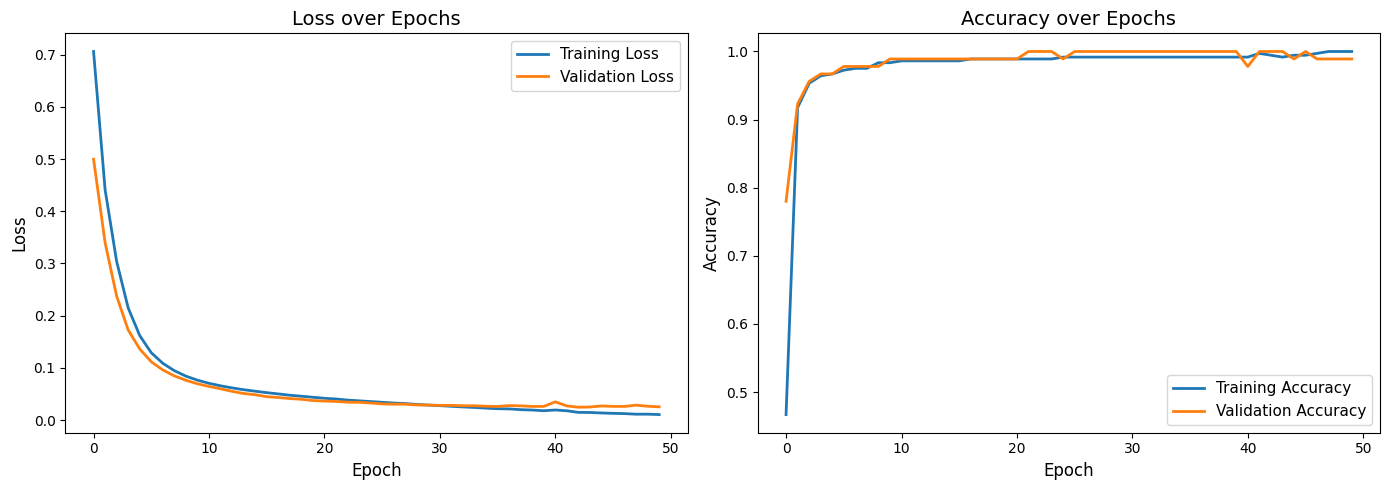

Train-Val accuracy gap: 0.0110
  ✓ Model generalizes well


In [28]:
# Create a figure with 1 row, 2 columns, figsize=(14, 5)

# LEFT: Loss curves
#   Plot history.history['loss'] — label 'Training Loss'
#   Plot history.history['val_loss'] — label 'Validation Loss'
#   Title: 'Loss over Epochs'
#   x-label: 'Epoch', y-label: 'Loss'
#   Add legend

# RIGHT: Accuracy curves
#   Plot history.history['accuracy'] — label 'Training Accuracy'
#   Plot history.history['val_accuracy'] — label 'Validation Accuracy'
#   Title: 'Accuracy over Epochs'
#   x-label: 'Epoch', y-label: 'Accuracy'
#   Add legend

# plt.tight_layout() and plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Overfitting check
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f"Train-Val accuracy gap: {gap:.4f}")
if gap > 0.05:
    print("  ⚠ Some overfitting detected — consider Dropout or Early Stopping")
else:
    print("  ✓ Model generalizes well")

**What to observe:**
- **Loss plot (left):** Both curves should decrease. If validation loss starts rising while training loss keeps dropping, that is overfitting — the model is memorizing training data.
- **Accuracy plot (right):** Both should increase. The gap between training and validation accuracy reveals overfitting.
- **Ideal:** Both curves converge and flatten. The closer they are, the better the model generalizes.
|

## 10. Evaluating on the Test Set

Just like with Scikit-learn models, we evaluate on the held-out test set that the model has never seen.

**Task:** Evaluate the model using `model.evaluate()` and generate predictions.

In [30]:
# Evaluate on test set:
# test_loss, test_accuracy = model.evaluate(X_test_sc, y_test, verbose=0)
# Print test loss and accuracy

# Get predicted probabilities:
# y_prob = model.predict(X_test_sc).flatten()

# Convert probabilities to class labels (threshold = 0.5):
# y_pred = (y_prob >= 0.5).astype(int)

# Print first 10 predictions vs actuals

test_loss, test_accuracy = model.evaluate(X_test_sc, y_test, verbose=0)

print("=" * 50)
print("  NEURAL NETWORK — Test Evaluation")
print("=" * 50)
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
print("=" * 50)

# Get predictions
y_prob = model.predict(X_test_sc, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Show first 10
comparison = pd.DataFrame({
    'Actual': y_test_org[:10],
    'Predicted': y_pred[:10],
    'Probability': y_prob[:10].round(4),
    'Correct': ['✓' if a == p else '✗' for a, p in zip(y_test_org[:10], y_pred[:10])]
})
print("\nFirst 10 Predictions:")
print(comparison.to_string(index=False))


  NEURAL NETWORK — Test Evaluation
  Test Loss:     0.0947
  Test Accuracy: 0.9649 (96.5%)

First 10 Predictions:
 Actual  Predicted  Probability Correct
      0          0       0.0000       ✓
      1          1       1.0000       ✓
      0          0       0.0000       ✓
      1          0       0.1899       ✗
      0          0       0.0000       ✓
      1          1       0.9978       ✓
      1          1       1.0000       ✓
      0          0       0.0000       ✓
      0          0       0.0000       ✓
      0          0       0.0000       ✓


### 10.1 Confusion Matrix and Classification Report

**Task:** Compute and display the confusion matrix and classification report.

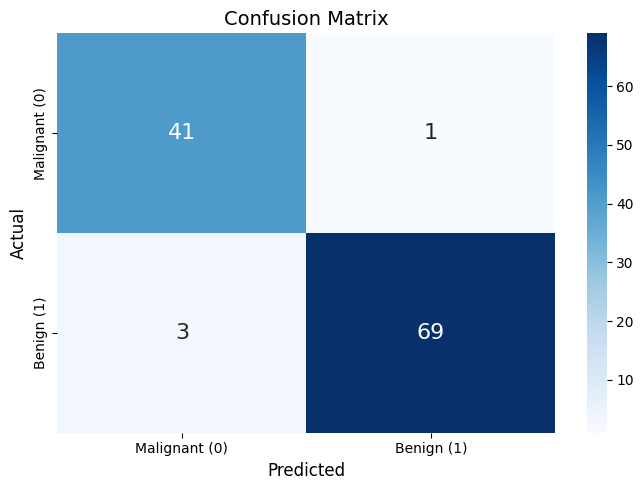

True Negatives  (TN): 41  — Correctly identified Malignant
False Positives (FP): 1  — Predicted Benign, was actually Malignant
False Negatives (FN): 3  — Predicted Malignant, was actually Benign
True Positives  (TP): 69  — Correctly identified Benign


In [31]:
# Compute confusion matrix

# Visualize with sns.heatmap, figsize=(7, 5)
# Labels: ['Malignant (0)', 'Benign (1)']
# Title: 'Confusion Matrix — Neural Network'
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(y_test_org, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly identified Malignant")
print(f"False Positives (FP): {fp}  — Predicted Benign, was actually Malignant")
print(f"False Negatives (FN): {fn}  — Predicted Malignant, was actually Benign")
print(f"True Positives  (TP): {tp}  — Correctly identified Benign")



In [32]:
print(classification_report(y_test_org, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



## 11. Improving the Model — Adding Dropout

If you noticed overfitting in the training curves (training accuracy much higher than validation), we can add **Dropout** layers. Dropout randomly "turns off" a fraction of neurons during each training step, preventing the network from relying too heavily on any single neuron.

Think of it like training a sports team by randomly benching players — every player must learn to contribute, not just the stars.

**Task:** Build a new model with Dropout layers.

In [44]:
# Build an improved model with Dropout:
# model_v2 = Sequential([
#     Dense(64, activation='relu', input_shape=(30,)),
#     Dropout(0.3),           # Drop 30% of neurons randomly
#     Dense(32, activation='relu'),
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')
# ])
from tensorflow.keras.optimizers import Adam

model_v2 = Sequential([
    Dense(64, activation='relu', input_shape=(30,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
# Compile with same settings
model_v2.compile(
    optimizer = Adam(learning_rate = 0.1),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)



In [45]:
model_v2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Train for 50 epochs with validation_split=0.2
history = model_v2.fit(
    X_train_sc, y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)

print(f"Training_ACCURACY, {history.history['accuracy'][-1]:.3f}")

print(f"Validation Accuracy, {history.history['val_accuracy'][-1]:.3f}")

# Print model summary


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8846 - loss: 0.4163 - val_accuracy: 0.9670 - val_loss: 0.2942
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9451 - loss: 0.4486 - val_accuracy: 0.9890 - val_loss: 0.0234
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.1962 - val_accuracy: 0.9780 - val_loss: 0.0473
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.0856 - val_accuracy: 0.9780 - val_loss: 0.1040
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.1036 - val_accuracy: 0.9890 - val_loss: 0.0301
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.1403 - val_accuracy: 0.9780 - val_loss: 0.0418
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1291 - val_accuracy: 0.9890 - val_loss: 0.0400
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9588 - loss: 0.0918 - val_accuracy: 0.9560 - val_loss

### 11.1 Compare Training Curves — With vs Without Dropout

**Task:** Plot the training curves of both models side by side.

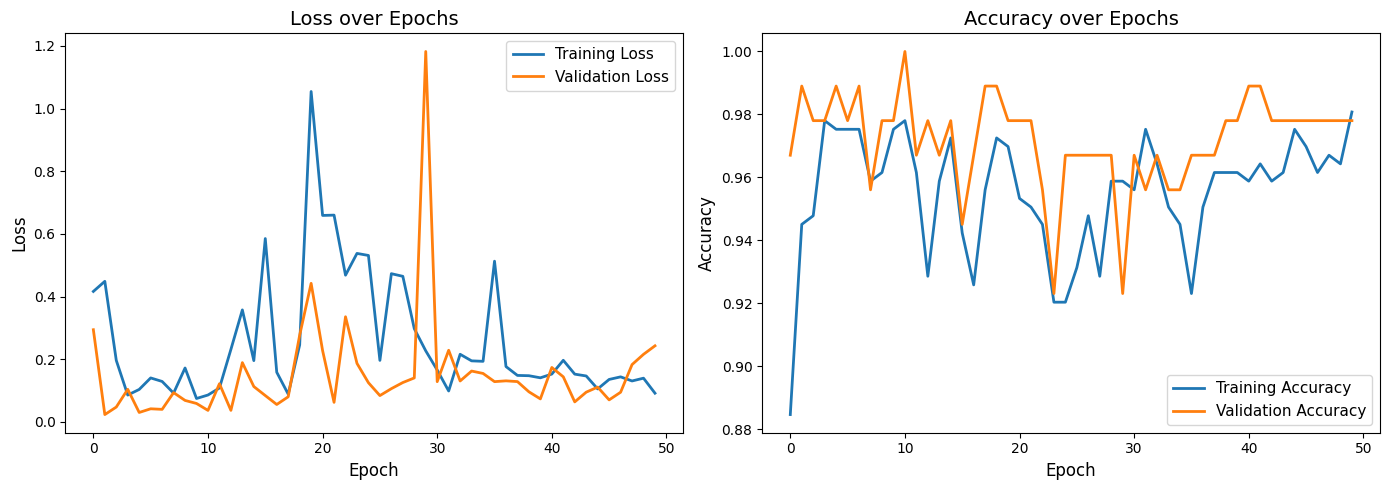

Train-Val accuracy gap: 0.0027
  ✓ Model generalizes well


In [47]:
# Create a figure with 1 row, 2 columns, figsize=(14, 5)

# LEFT: Loss curves
#   Plot history.history['loss'] — label 'Training Loss'
#   Plot history.history['val_loss'] — label 'Validation Loss'
#   Title: 'Loss over Epochs'
#   x-label: 'Epoch', y-label: 'Loss'
#   Add legend

# RIGHT: Accuracy curves
#   Plot history.history['accuracy'] — label 'Training Accuracy'
#   Plot history.history['val_accuracy'] — label 'Validation Accuracy'
#   Title: 'Accuracy over Epochs'
#   x-label: 'Epoch', y-label: 'Accuracy'
#   Add legend

# plt.tight_layout() and plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Overfitting check
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f"Train-Val accuracy gap: {gap:.4f}")
if gap > 0.05:
    print("  ⚠ Some overfitting detected — consider Dropout or Early Stopping")
else:
    print("  ✓ Model generalizes well")

**What to observe:** With Dropout, the gap between training and validation accuracy should be smaller. Training accuracy may be slightly lower (Dropout makes training harder), but validation accuracy should be similar or better — the model generalizes better.


## 12. Early Stopping — Stop Before Overfitting

Instead of guessing the right number of epochs, we can use **Early Stopping** — a callback that monitors validation loss and stops training when it stops improving. This is the most practical way to prevent overfitting.

**Task:** Train with Early Stopping.

In [50]:
# From tensorflow.keras.callbacks import EarlyStopping

# Define early stopping:
# early_stop = EarlyStopping(
#     monitor='val_loss',      # Watch validation loss
#     patience=10,             # Wait 10 epochs for improvement
#     restore_best_weights=True # Restore the best model, not the last one
# )

# Build and compile a fresh model (same architecture as model_v2)

# Train with early stopping:
# history_es = model_v3.fit(
#     X_train_sc, y_train,
#     epochs=200,              # Set high — early stopping will handle it
#     batch_size=32,
#     validation_split=0.2,
#     callbacks=[early_stop],
#     verbose=1
# )

# Print how many epochs actually ran

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_v3 = Sequential([
    Dense(64, activation='relu', input_shape=(30,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_v3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_v3 = model_v3.fit(
    X_train_sc, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose= 1
)

v3_loss, v3_acc = model_v3.evaluate(X_test_sc, y_test, verbose=0)
epochs_ran = len(history_v3.history['loss'])

print(f"\nEarly Stopping Results:")
print(f"  Epochs set:    200")
print(f"  Epochs ran:    {epochs_ran}")
print(f"  Epochs saved:  {200 - epochs_ran}")
print(f"  Test Accuracy: {v3_acc:.4f}")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7445 - loss: 0.5494 - val_accuracy: 0.8791 - val_loss: 0.3888
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9121 - loss: 0.3281 - val_accuracy: 0.9451 - val_loss: 0.2680
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.2303 - val_accuracy: 0.9560 - val_loss: 0.2010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - loss: 0.2035 - val_accuracy: 0.9670 - val_loss: 0.1587
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9368 - loss: 0.1683 - val_accuracy: 0.9670 - val_loss: 0.1277
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9588 - loss: 0.1345 - val_accuracy: 0.9780 - val_loss: 0.1045
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.1208 - val_accuracy: 0.9780 - val_loss: 0.0901
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9698 - loss: 0.1007 - val_accuracy: 0.9780 - 

**What to observe:** Even though we set `epochs=200`, training stopped much earlier — Early Stopping detected that validation loss was no longer improving and halted training. The `restore_best_weights=True` parameter ensures we keep the model from the epoch with the lowest validation loss, not the last epoch.


## 13. Neural Network vs Classical ML — Final Comparison

Let us see how our neural network stacks up against the models we built in previous lectures.

**Task:** Compare NN with Logistic Regression, SVM, and Random Forest.

In [51]:
# From sklearn.linear_model import LogisticRegression
# From sklearn.svm import SVC
# From sklearn.ensemble import RandomForestClassifier

# Train each sklearn model on scaled data (LR, SVM) or unscaled (RF)

# For each model + the neural network:
#   Compute test accuracy

# Display comparison table

# Print insights: is the NN significantly better?

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classical models
lr = LogisticRegression(random_state=42, max_iter=5000)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test_org, lr.predict(X_test_sc))

svm = SVC(random_state=42, probability=True)
svm.fit(X_train_sc, y_train)
svm_acc = accuracy_score(y_test_org, svm.predict(X_test_sc))

# RF on unscaled data
X_train_raw, X_test_raw = train_test_split(
    cancer.data, test_size=0.2, random_state=42, stratify=cancer.target
)[:2]
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_raw, cancer.target[train_test_split(
    np.arange(len(cancer.target)), test_size=0.2, random_state=42, stratify=cancer.target
)[0]])
rf_acc = accuracy_score(y_test_org, rf.predict(X_test_raw))

# NN result
nn_acc = v3_acc

results = [
    {'Model': 'Logistic Regression', 'Test Accuracy': round(lr_acc, 4)},
    {'Model': 'SVM (RBF)', 'Test Accuracy': round(svm_acc, 4)},
    {'Model': 'Random Forest', 'Test Accuracy': round(rf_acc, 4)},
    {'Model': 'Neural Network (Keras)', 'Test Accuracy': round(nn_acc, 4)}
]

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)

print("=" * 50)
print("  FINAL COMPARISON — All Models")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)
print(f"\nWinner: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Test Accuracy']})")


  FINAL COMPARISON — All Models
                 Model  Test Accuracy
   Logistic Regression         0.9825
             SVM (RBF)         0.9825
         Random Forest         0.9561
Neural Network (Keras)         0.9561

Winner: Logistic Regression (0.9825)


**What to observe:** On this small, tabular dataset (569 samples, 30 features), the neural network may perform comparably to — or even slightly worse than — classical ML models like Random Forest or SVM. This is expected! Deep learning shines on large datasets and unstructured data (images, text, audio). For small tabular data, classical ML is often the better choice.


## 14. Saving and Loading Models

After training, you can save the model to disk and load it later — for deployment, sharing, or continued training.

**Task:** Save and reload the model.

In [52]:
# Save
model_v3.save('breast_cancer_nn.keras')
print("Model saved to 'breast_cancer_nn.keras'")



Model saved to 'breast_cancer_nn.keras'


In [53]:
loaded_model = tf.keras.models.load_model('breast_cancer_nn.keras')
loaded_loss, loaded_acc = loaded_model.evaluate(X_test_sc, y_test, verbose=0)
print(f"Loaded model test accuracy: {loaded_acc:.4f} (should match original: {v3_acc:.4f})")

Loaded model test accuracy: 0.9561 (should match original: 0.9561)


## 15. Summary and Key Takeaways

**TensorFlow & Keras:**
- TensorFlow = the deep learning engine (Google). Keras = the simple high-level API.
- Since TF 2.x, Keras is built into TensorFlow as `tf.keras`.
- Tensors are multi-dimensional arrays — the fundamental data structure.

**The Keras Workflow:**

| Step | Code | What It Does |
|------|------|--------------|
| 1. Define | `Sequential([Dense(...), ...])` | Stack layers |
| 2. Compile | `model.compile(optimizer, loss, metrics)` | Configure training |
| 3. Fit | `model.fit(X, y, epochs, batch_size)` | Train the model |
| 4. Evaluate | `model.evaluate(X_test, y_test)` | Test performance |
| 5. Predict | `model.predict(X_new)` | Get predictions |

**Key Components:**
- **Dense layer** — Fully connected layer (every neuron connected to every input)
- **Activation** — ReLU for hidden layers, Sigmoid for binary output, Softmax for multi-class
- **Optimizer** — Adam is the default go-to
- **Loss** — Binary Crossentropy for binary classification, Categorical Crossentropy for multi-class
- **Dropout** — Regularization that randomly disables neurons during training
- **Early Stopping** — Automatically stops training when validation loss stops improving

**Practical Tips:**
- Always scale features before feeding to a neural network
- Convert data to float32
- Plot training curves — they are your best diagnostic tool
- Use Dropout + Early Stopping to prevent overfitting
- For small tabular data, classical ML is often better — use NNs when you have lots of data or unstructured input

**What comes next:** Convolutional Neural Networks (CNNs) for image data, and more advanced architectures.

---

*End of Lecture — Student Notebook*